In [ ]:
# Notebook 05 - Coastal Water Quality Feature Mapping

## Objective

This notebook uses Planet Tanager hyperspectral surface reflectance to investigate spatial variations in the optical properties of coastal waters in Corozal Bay, Belize.

The analysis focuses on relative spectral indicators rather than absolute concentrations of water-quality parameters because no coincident field measurements were taken for calibration.

## Planned analysis

1. Load the Tanager hyperspectral cube and metadata.
2. Apply the previously developed coastal water mask.
3. Remove unreliable spectral wavelengths.
4. Calculate relative spectral indicators.
5. Map their spatial distribution
6. Compare the indicators with RGB imagery and spectral classes.

## Importanst limitation

The resulting maps represent relative spectral patterns and should not be interpreted as calibrated measurements of turbidity, chlorophyll-a, or suspended sediment concentration without independent field observations or a validated retrieval model.

In [1]:
#01_Import Data
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = False

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")

OUTPUT_DIR = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready.")

Environment ready.


In [2]:
#02_Load the Tanager data
with h5py.File(DATA_PATH, "r") as f:
    
    sr_dataset = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]

    cube = sr_dataset[:]

    wavelengths = sr_dataset.attrs["wavelengths"]

    good_wavelengths = sr_dataset.attrs["good_wavelengths"]

    cloud_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]

    cirrus_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask"][:]

    nodata_mask = f["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]
    
cube = cube.astype(np.float32)

cube[cube == -9999.0] = np.nan

good_wavelengths = good_wavelengths.astype(bool)

print("Cube shape:", cube.shape)
print("Number of wavelengths:", len(wavelengths))
print("Good wavelengths:", np.sum(good_wavelengths))

Cube shape: (426, 671, 763)
Number of wavelengths: 426
Good wavelengths: 368


In [3]:
#03_Understand the water mask
WATER_MASK_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\maps\water_mask.npy")

water_mask = np.load(WATER_MASK_PATH)
print("Water mask shape:", water_mask.shape)
print("Water pixels:", np.sum(water_mask))
print("Water size:", water_mask.size)
print("Water percentage:", np.sum(water_mask)/water_mask.size * 100)

Water mask shape: (671, 763)
Water pixels: 103239
Water size: 511973
Water percentage: 20.16493057251066


In [4]:
#04_Create a clean analysis mask
valid_water = (water_mask
               & (cloud_mask == 0)
               & (cirrus_mask == 0)
               & (nodata_mask == 0)
              )

print("Valid water pixels:", np.sum(valid_water))

Valid water pixels: 103239


In [5]:
#05_Find spectral bands

def find_band(target_nm):
    return np.argmin(np.abs(wavelengths - target_nm))

blue_490 = find_band(490)
green_560 = find_band(560)
red_665 = find_band(665)
red_edge_705 = find_band(705)
nir_865 = find_band(865)

print("Selected spectral bands")
print("="*60)

print(f"Blue     : Band {blue_490} | {wavelengths[blue_490]:.2f} nm")
print(f"Green    : Band {green_560} | {wavelengths[green_560]:.2f} nm")
print(f"Red      : Band {red_665} | {wavelengths[red_665]:.2f} nm")
print(f"Red Edge : Band {red_edge_705} | {wavelengths[red_edge_705]:.2f} nm")
print(f"NIR      : Band {nir_865} | {wavelengths[nir_865]:.2f} nm")

Selected spectral bands
Blue     : Band 23 | 490.93 nm
Green    : Band 37 | 560.83 nm
Red      : Band 58 | 665.87 nm
Red Edge : Band 66 | 705.92 nm
NIR      : Band 98 | 866.28 nm


In [6]:
#06_Check wavelength quality

selected_bands = {"Blue": blue_490,
                  "Green": green_560,
                  "Red": red_665,
                  "Red Edge": red_edge_705,
                  "NIR": nir_865}

print("Wavelength Quality Check")
print("=" * 60)

for name, band in selected_bands.items():

    status = "GOOD" if good_wavelengths[band] else "FLAGGED"

    print(f"{name:10s} | "f"Band {band:3d} | "f"{wavelengths[band]:8.2f} nm |"
         f"{status}")

Wavelength Quality Check
Blue       | Band  23 |   490.93 nm |GOOD
Green      | Band  37 |   560.83 nm |GOOD
Red        | Band  58 |   665.87 nm |GOOD
Red Edge   | Band  66 |   705.92 nm |GOOD
NIR        | Band  98 |   866.28 nm |GOOD


In [7]:
#07_Extract spectral layers

blue_layer = cube[blue_490]
green_layer = cube[green_560]
red_layer = cube[red_665]
red_edge_layer = cube[red_edge_705]
nir_layer = cube[nir_865]

print("Spectral layers extracted.")
print("Layer shape:", nir_layer.shape)


Spectral layers extracted.
Layer shape: (671, 763)


In [8]:
#08_Apply water mask

blue_water = np.where(valid_water, blue_layer, np.nan)
green_water = np.where(valid_water, green_layer, np.nan)
red_water = np.where(valid_water, red_layer, np.nan)
red_edge_water = np.where(valid_water, red_edge_layer, np.nan)
nir_water = np.where(valid_water, nir_layer, np.nan)

print("Water-only spectral layers created.")


Water-only spectral layers created.


In [9]:
#09_Calculate relative spectral indicators

green_blue_ratio = green_water / blue_water

red_green_ratio = red_water / green_water

nir_red_ratio = nir_water / red_water

print("Spectral indicators calculated.")

Spectral indicators calculated.


In [10]:
#10_Clean spectral indicators

def clean_ratio(layer, lower=1, upper=99):
    layer = layer.astype(np.float32).copy()
    layer[~np.isfinite(layer)] = np.nan

    low = np.nanpercentile(layer, lower)
    high = np.nanpercentile(layer, upper)

    layer[layer < low] = np.nan
    layer[layer > high] = np.nan

    return layer

green_blue_clean = clean_ratio(green_blue_ratio)
red_green_clean = clean_ratio(red_green_ratio)
nir_red_clean = clean_ratio(nir_red_ratio)

print("Spectral indicators cleaned.")

Spectral indicators cleaned.


In [11]:
#11_Indicator statistics

def show_statistics(name, layer):
    values = layer[np.isfinite(layer)]

    print(f"\n{name}")
    print("="*50)
    print(f"Valid Pixels     : {len(values):,}")
    print(f"Minimum          : {np.min(values):.4f}")
    print(f"5th percentile   : {np.nanpercentile(values, 5):.4f}")
    print(f"50th percentile   : {np.nanpercentile(values, 50):.4f}")
    print(f"95th percentile   : {np.nanpercentile(values, 95):.4f}")
    print(f"99th percentile   : {np.nanpercentile(values,99):.4f}")
    print(f"Maximum          : {np.max(values):.4f}")

show_statistics("Green / Blue Ratio", green_blue_clean)
show_statistics("Red / Green Ratio", red_green_clean)
show_statistics("NIR / Red Ratio", nir_red_clean)


Green / Blue Ratio
Valid Pixels     : 101,173
Minimum          : 1.0408
5th percentile   : 1.0928
50th percentile   : 1.2213
95th percentile   : 1.3183
99th percentile   : 1.3730
Maximum          : 1.4278

Red / Green Ratio
Valid Pixels     : 101,173
Minimum          : 0.5888
5th percentile   : 0.6506
50th percentile   : 0.7331
95th percentile   : 0.8230
99th percentile   : 0.8874
Maximum          : 0.8987

NIR / Red Ratio
Valid Pixels     : 101,173
Minimum          : 0.6717
5th percentile   : 0.7861
50th percentile   : 0.9210
95th percentile   : 1.1256
99th percentile   : 3.1615
Maximum          : 4.3777


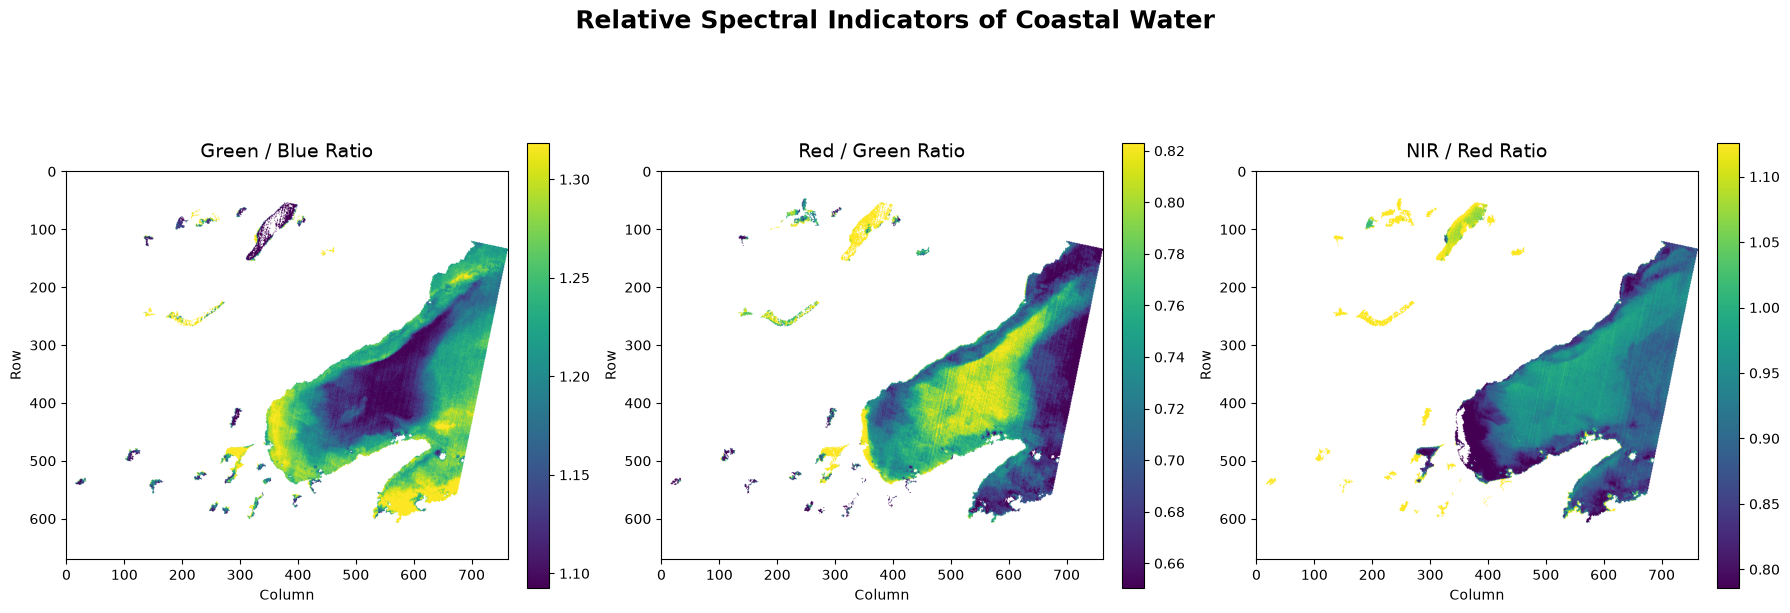

In [12]:
#12_Map spectral indicators

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

indicators = [("Green / Blue Ratio", green_blue_clean),
              ("Red / Green Ratio", red_green_clean),
              ("NIR / Red Ratio", nir_red_clean)]

for ax, (title, layer) in zip(axes, indicators):

    vmin, vmax = np.nanpercentile(layer, [5, 95])

    im = ax.imshow(layer, vmin=vmin, vmax=vmax)

    ax.set_title(f"{title}", fontsize=14, pad=10)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Relative Spectral Indicators of Coastal Water", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#13_Compare spectral indicators

import pandas as pd

indicator_data = {"Green / Blue": green_blue_clean,
                  "Red / Green": red_green_clean,
                  "NIR / Red": nir_red_clean}

percentiles = [5, 25, 50, 75, 95]

comparison = {}

for name, layer in indicator_data.items():
    values = layer[np.isfinite(layer)]
    comparison[name] = [np.percentile(values, p) for p in percentiles]

comparison_df = pd.DataFrame(comparison, index=["5th Percentile",
                                                "25th Percentile",
                                                "50th Percentile",
                                                "75th Percentile",
                                                "95th Percentile",])

print("Spectral Indicator Comparison")
print("="*70)

display(comparison_df.round(4))



Spectral Indicator Comparison


,Green / Blue,Red / Green,NIR / Red
5th Percentile,1.0928,0.6506,0.7861
25th Percentile,1.1487,0.6873,0.8751
50th Percentile,1.2213,0.7331,0.9210
75th Percentile,1.2578,0.7842,0.9641
95th Percentile,1.3183,0.8230,1.1256


In [14]:
#14_Robust variability comparison

print("Robust Variability of Spectral Indicators")
print("="*65)

for name , layer in indicator_data.items():
    values = layer[np.isfinite(layer)]

    q25 = np.percentile(values, 25)
    q50 = np.percentile(values, 50)
    q75 = np.percentile(values, 75)

    iqr = q75 - q25
    relative_iqr = iqr / q50

    print(f"\n{name}")
    print(f"25th percentile : {q25:.4f}")
    print(f"50th percentile : {q50:.4f}")
    print(f"75th percentile : {q75:.4f}")
    print(f"IQR             : {iqr:.4f}")
    print(f"Relative IQR    : {relative_iqr:.2%}")

Robust Variability of Spectral Indicators

Green / Blue
25th percentile : 1.1487
50th percentile : 1.2213
75th percentile : 1.2578
IQR             : 0.1091
Relative IQR    : 8.93%

Red / Green
25th percentile : 0.6873
50th percentile : 0.7331
75th percentile : 0.7842
IQR             : 0.0970
Relative IQR    : 13.23%

NIR / Red
25th percentile : 0.8751
50th percentile : 0.9210
75th percentile : 0.9641
IQR             : 0.0890
Relative IQR    : 9.67%


In [15]:
#15_Correlation between spectral indicators

# Creation of DataFrame containing all three indicators
indicator_arrays = {"Green / Blue": green_blue_clean,
                    "Red / Green": red_green_clean,
                    "NIR / Red": nir_red_clean}

# Flatten each spatial layer into a column
indicator_df = pd.DataFrame({name: layer.flatten()
                             for name, layer in indicator_arrays.items()})

# Keep only pixels where all three indicators are valid
indicator_df = indicator_df.dropna()

print("Correlation dataset")
print("=" * 60)
print(f"Valid pixel observations: {len(indicator_df):,}")


# Pearson correlation
correlation_matrix = indicator_df.corr(method="pearson")

print("Pearson Correlation Matrix")
print("=" * 60)

display(correlation_matrix.round(4))

Correlation dataset
Valid pixel observations: 98,103
Pearson Correlation Matrix


,Green / Blue,Red / Green,NIR / Red
Green / Blue,1.0000,-0.6169,-0.1304
Red / Green,-0.6169,1.0000,0.0235
NIR / Red,-0.1304,0.0235,1.0000


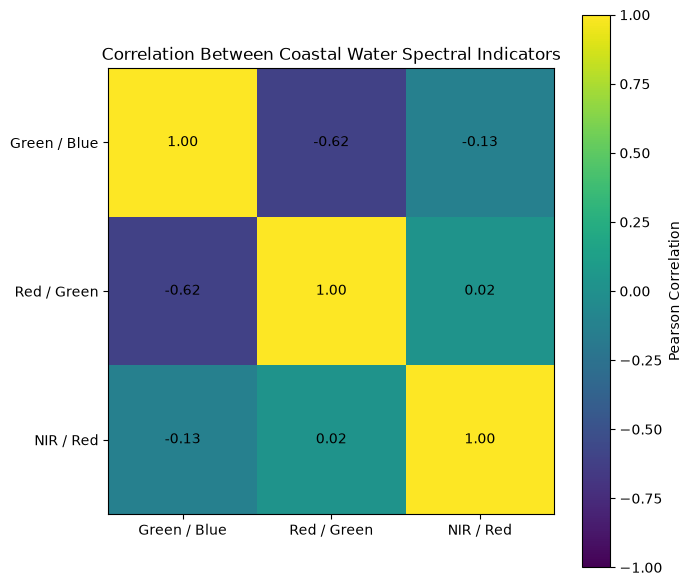

In [16]:
#16_Correlation heatmap

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(correlation_matrix, vmin=-1, vmax=1)

# Axis labels
labels = correlation_matrix.columns

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Add correlation values
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation Between Coastal Water Spectral Indicators")

plt.colorbar(im, ax=ax, label="Pearson Correlation")

plt.tight_layout()
plt.show()

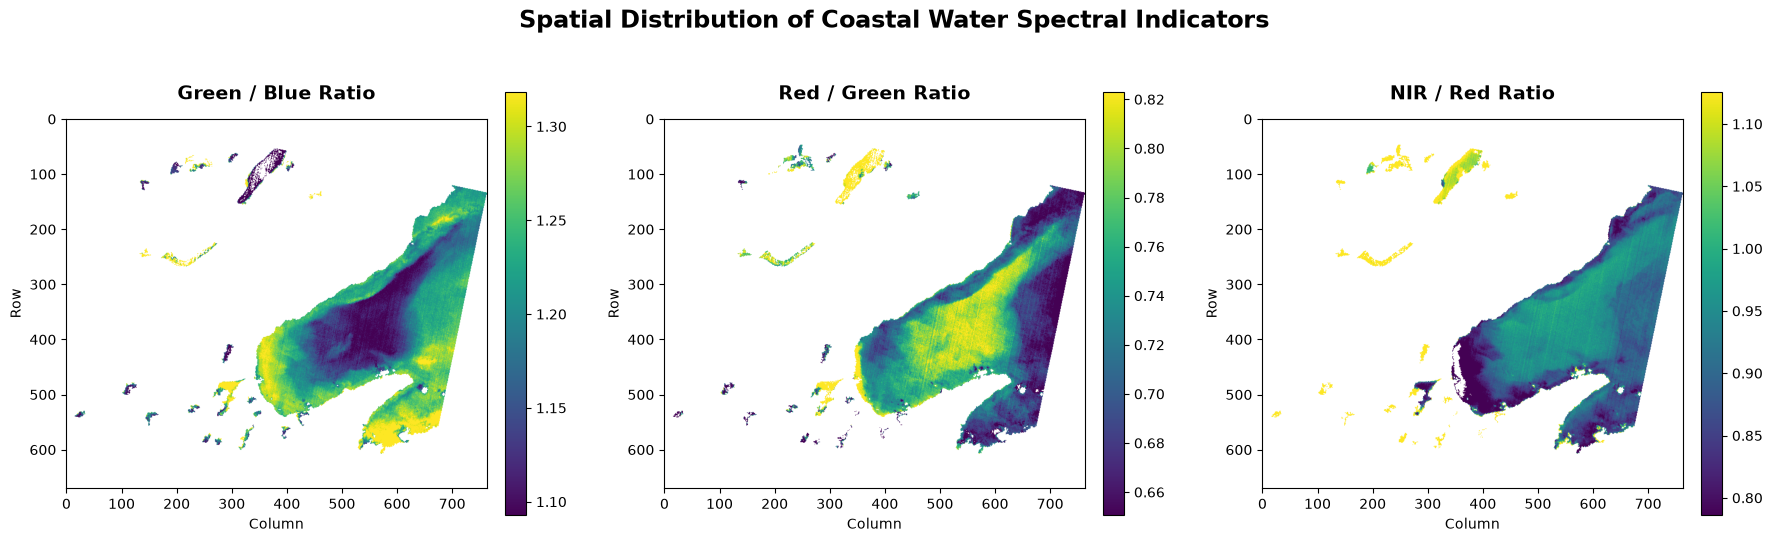

In [17]:
#17_Spatial Distribution of Spectral Indicators

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

indicator_layers = [("Green / Blue Ratio", green_blue_clean),
                    ("Red / Green Ratio", red_green_clean),
                    ("NIR / Red Ratio", nir_red_clean)]

for ax, (name, layer) in zip(axes, indicator_layers):

    # 5th–95th percentile display range
    vmin = np.nanpercentile(layer, 5)
    vmax = np.nanpercentile(layer, 95)

    im = ax.imshow(layer, vmin=vmin, vmax=vmax, cmap="viridis")

    # Explicit subplot title
    ax.text(0.5, 1.04, name, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "Spatial Distribution of Coastal Water Spectral Indicators",
    fontsize=17, fontweight="bold", y=0.98)

# Manually control spacing
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.04, right=0.96, wspace=0.30)

plt.show()

In [18]:
#18_Exploratory spatial zones within coastal water

rows, cols = water_mask.shape

# Create row coordinates
row_grid = np.arange(rows)[:, None]

# Repeat across columns
row_grid = np.broadcast_to(row_grid, water_mask.shape)

# Define three exploratory spatial zones
zone_labels = np.full(water_mask.shape, np.nan)

zone_labels[
    water_mask & (row_grid < 300)
] = 1

zone_labels[
    water_mask & (row_grid >= 300) & (row_grid < 450)
] = 2

zone_labels[
    water_mask & (row_grid >= 450)
] = 3

print("Exploratory water zones")
print("=" * 50)

for zone in [1, 2, 3]:

    count = np.sum(zone_labels == zone)

    print(f"Zone {zone}: {count:,} pixels")

Exploratory water zones
Zone 1: 26,570 pixels
Zone 2: 46,262 pixels
Zone 3: 30,407 pixels


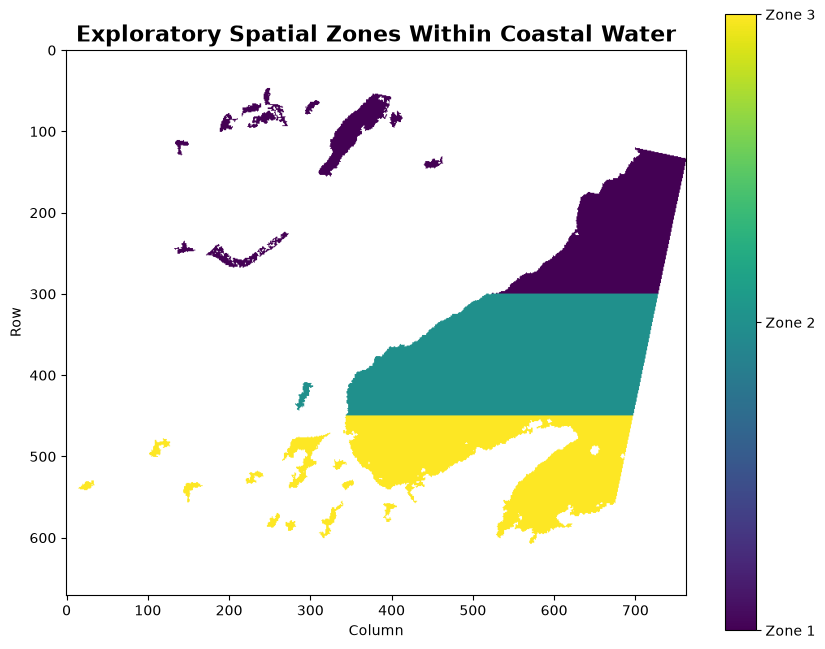

In [19]:
#19_Visualize exploratory water zones

fig, ax = plt.subplots(figsize=(10, 8))

display_zones = np.ma.masked_where(
    ~water_mask,
    zone_labels
)

im = ax.imshow(
    display_zones,
    cmap="viridis",
    vmin=1,
    vmax=3
)

ax.set_title(
    "Exploratory Spatial Zones Within Coastal Water",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Zone 1",
    "Zone 2",
    "Zone 3"
])

plt.show()

In [20]:
#20_Identify connected water regions

from scipy import ndimage

# Label connected components
labeled_water, num_features = ndimage.label(
    water_mask.astype(np.uint8)
)

# Count pixels in each component
component_sizes = np.bincount(
    labeled_water.ravel()
)

# Ignore background (label 0)
component_sizes[0] = 0

# Find the largest connected component
main_component = np.argmax(component_sizes)

main_water_mask = (
    labeled_water == main_component
)

print("Number of connected water regions:", num_features)
print("Main water body pixels:", np.sum(main_water_mask))
print(
    "Main water body percentage:",
    100 * np.sum(main_water_mask) / water_mask.size
)

Number of connected water regions: 24
Main water body pixels: 94550
Main water body percentage: 18.467770761348742


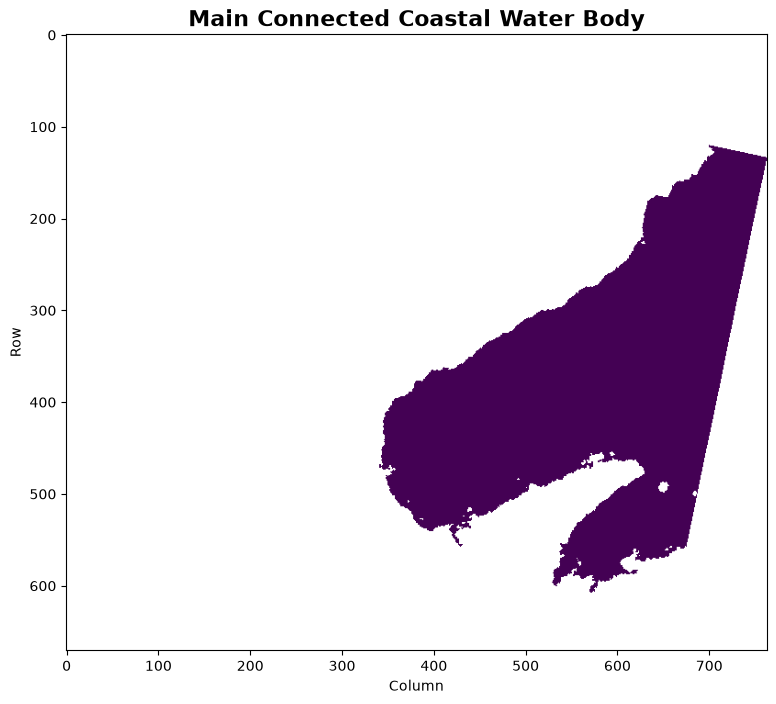

In [21]:
#21_Visualize main connected water body

fig, ax = plt.subplots(figsize=(10, 8))

display_main_water = np.ma.masked_where(
    ~main_water_mask,
    main_water_mask
)

im = ax.imshow(
    display_main_water,
    cmap="viridis"
)

ax.set_title(
    "Main Connected Coastal Water Body",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

plt.show()

In [22]:
#22_Create exploratory spatial zones

row_indices = np.indices(main_water_mask.shape)[0]

zones = np.zeros_like(main_water_mask, dtype=np.uint8)

# Zone 1: Northern / outer-water region
zones[
    main_water_mask & (row_indices < 300)
] = 1

# Zone 2: Central-water region
zones[
    main_water_mask &
    (row_indices >= 300) &
    (row_indices < 450)
] = 2

# Zone 3: Southern / nearshore region
zones[
    main_water_mask & (row_indices >= 450)
] = 3


print("Exploratory zones within main water body")
print("=" * 50)

for zone_id in [1, 2, 3]:
    print(
        f"Zone {zone_id}:",
        np.sum(zones == zone_id),
        "pixels"
    )

Exploratory zones within main water body
Zone 1: 21059 pixels
Zone 2: 45978 pixels
Zone 3: 27513 pixels


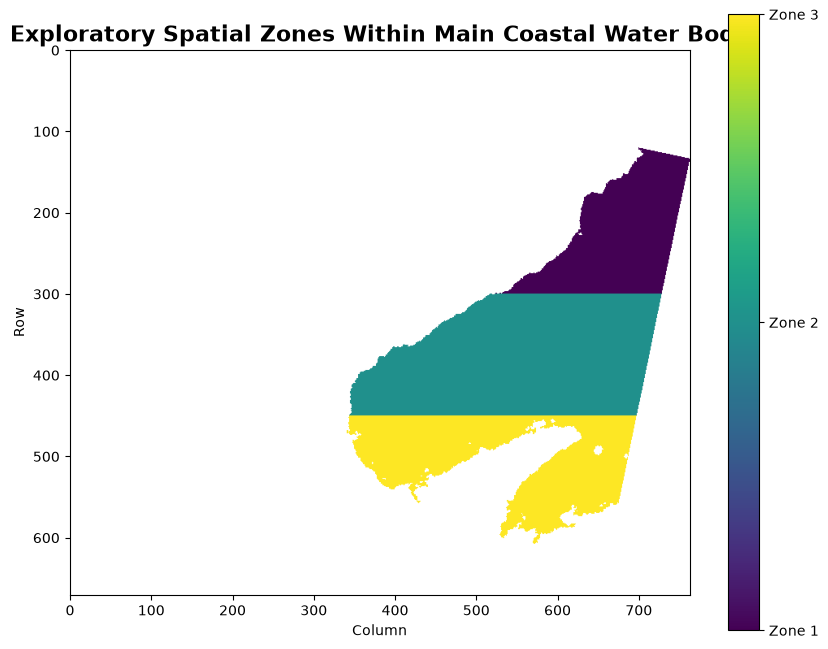

In [23]:
#23_Visualize exploratory zones

fig, ax = plt.subplots(figsize=(10, 8))

zone_display = np.ma.masked_where(
    zones == 0,
    zones
)

im = ax.imshow(
    zone_display,
    cmap="viridis",
    vmin=1,
    vmax=3
)

ax.set_title(
    "Exploratory Spatial Zones Within Main Coastal Water Body",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

cbar = plt.colorbar(im, ax=ax)
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels([
    "Zone 1",
    "Zone 2",
    "Zone 3"
])

plt.show()

In [24]:
#24_Extract spectral indicators by zone

zone_statistics = {}

indicator_layers = {
    "Green / Blue": green_blue_clean,
    "Red / Green": red_green_clean,
    "NIR / Red": nir_red_clean
}

for zone_id in [1, 2, 3]:

    zone_mask = zones == zone_id

    zone_statistics[zone_id] = {}

    print(f"\nZone {zone_id}")
    print("=" * 60)

    for name, layer in indicator_layers.items():

        values = layer[zone_mask]
        values = values[np.isfinite(values)]

        zone_statistics[zone_id][name] = values

        print(f"{name}")
        print(f"  Valid pixels : {len(values):,}")
        print(f"  5th percentile  : {np.percentile(values, 5):.4f}")
        print(f"  Median          : {np.median(values):.4f}")
        print(f"  95th percentile : {np.percentile(values, 95):.4f}")


Zone 1
Green / Blue
  Valid pixels : 21,059
  5th percentile  : 1.1044
  Median          : 1.2112
  95th percentile : 1.2614
Red / Green
  Valid pixels : 21,059
  5th percentile  : 0.6449
  Median          : 0.7045
  95th percentile : 0.8036
NIR / Red
  Valid pixels : 21,059
  5th percentile  : 0.8279
  Median          : 0.9289
  95th percentile : 0.9848

Zone 2
Green / Blue
  Valid pixels : 45,978
  5th percentile  : 1.0907
  Median          : 1.1846
  95th percentile : 1.2911
Red / Green
  Valid pixels : 45,945
  5th percentile  : 0.6539
  Median          : 0.7533
  95th percentile : 0.8191
NIR / Red
  Valid pixels : 45,580
  5th percentile  : 0.8183
  Median          : 0.9431
  95th percentile : 0.9879

Zone 3
Green / Blue
  Valid pixels : 27,504
  5th percentile  : 1.1605
  Median          : 1.2625
  95th percentile : 1.3440
Red / Green
  Valid pixels : 27,175
  5th percentile  : 0.6592
  Median          : 0.7307
  95th percentile : 0.7965
NIR / Red
  Valid pixels : 26,752
  5th p

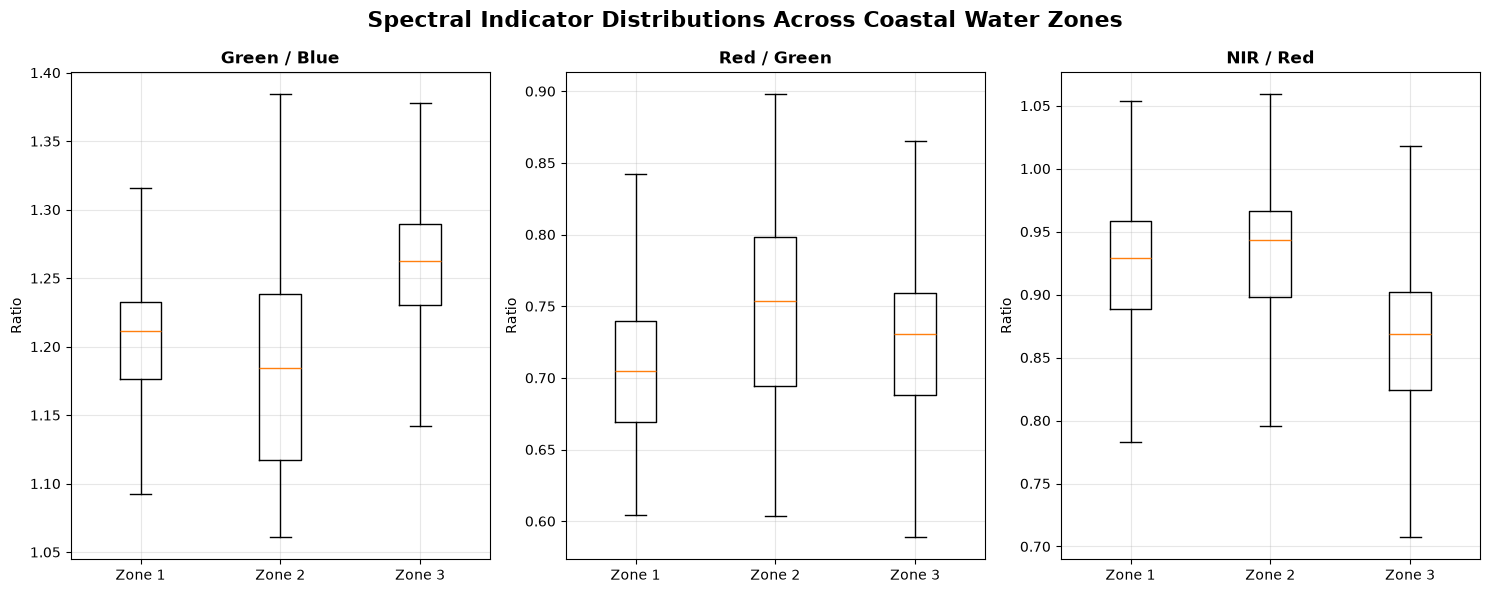

In [25]:
#25_Compare spectral indicators between zones

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 6)
)

indicator_names = [
    "Green / Blue",
    "Red / Green",
    "NIR / Red"
]

for ax, name in zip(axes, indicator_names):

    data = [
        zone_statistics[1][name],
        zone_statistics[2][name],
        zone_statistics[3][name]
    ]

    ax.boxplot(
        data,
        tick_labels=["Zone 1", "Zone 2", "Zone 3"],
        showfliers=False
    )

    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Ratio")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Spectral Indicator Distributions Across Coastal Water Zones",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [27]:
#26_Compare zone median differences

median_values = {
    "Green / Blue": {
        "Zone 1": 1.2112,
        "Zone 2": 1.1846,
        "Zone 3": 1.2625
    },

    "Red / Green": {
        "Zone 1": 0.7045,
        "Zone 2": 0.7533,
        "Zone 3": 0.7307
    },

    "NIR / Red": {
        "Zone 1": 0.9289,
        "Zone 2": 0.9431,
        "Zone 3": 0.8687
    }
}

print("Median Spectral Indicator Values")
print("=" * 60)

for indicator, zones in median_values.items():

    print(f"\n{indicator}")

    for zone, value in zones.items():
        print(f"  {zone}: {value:.4f}")

    values = list(zones.values())

    minimum = min(values)
    maximum = max(values)

    difference = ((maximum - minimum) / minimum) * 100

    print(
        f"  Difference between lowest and highest: "
        f"{difference:.2f}%"
    )

Median Spectral Indicator Values

Green / Blue
  Zone 1: 1.2112
  Zone 2: 1.1846
  Zone 3: 1.2625
  Difference between lowest and highest: 6.58%

Red / Green
  Zone 1: 0.7045
  Zone 2: 0.7533
  Zone 3: 0.7307
  Difference between lowest and highest: 6.93%

NIR / Red
  Zone 1: 0.9289
  Zone 2: 0.9431
  Zone 3: 0.8687
  Difference between lowest and highest: 8.56%


In [28]:
#27_Final summary table

summary_rows = []

for indicator, zones in median_values.items():

    values = list(zones.values())

    minimum = min(values)
    maximum = max(values)

    difference = ((maximum - minimum) / minimum) * 100

    summary_rows.append({
        "Indicator": indicator,
        "Zone 1 Median": zones["Zone 1"],
        "Zone 2 Median": zones["Zone 2"],
        "Zone 3 Median": zones["Zone 3"],
        "Lowest Median": minimum,
        "Highest Median": maximum,
        "Difference_Percent": difference
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Indicator,Zone 1 Median,Zone 2 Median,Zone 3 Median,Lowest Median,Highest Median,Difference_Percent
0,Green / Blue,1.2112,1.1846,1.2625,1.1846,1.2625,6.576059
1,Red / Green,0.7045,0.7533,0.7307,0.7045,0.7533,6.926899
2,NIR / Red,0.9289,0.9431,0.8687,0.8687,0.9431,8.564522


In [29]:
#28_Export numerical results

OUTPUT_DIR = Path(
    r"C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_05"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_path = OUTPUT_DIR / "coastal_water_spectral_indicator_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False
)

print("Summary table exported:")
print(summary_path)

Summary table exported:
C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_05\coastal_water_spectral_indicator_summary.csv


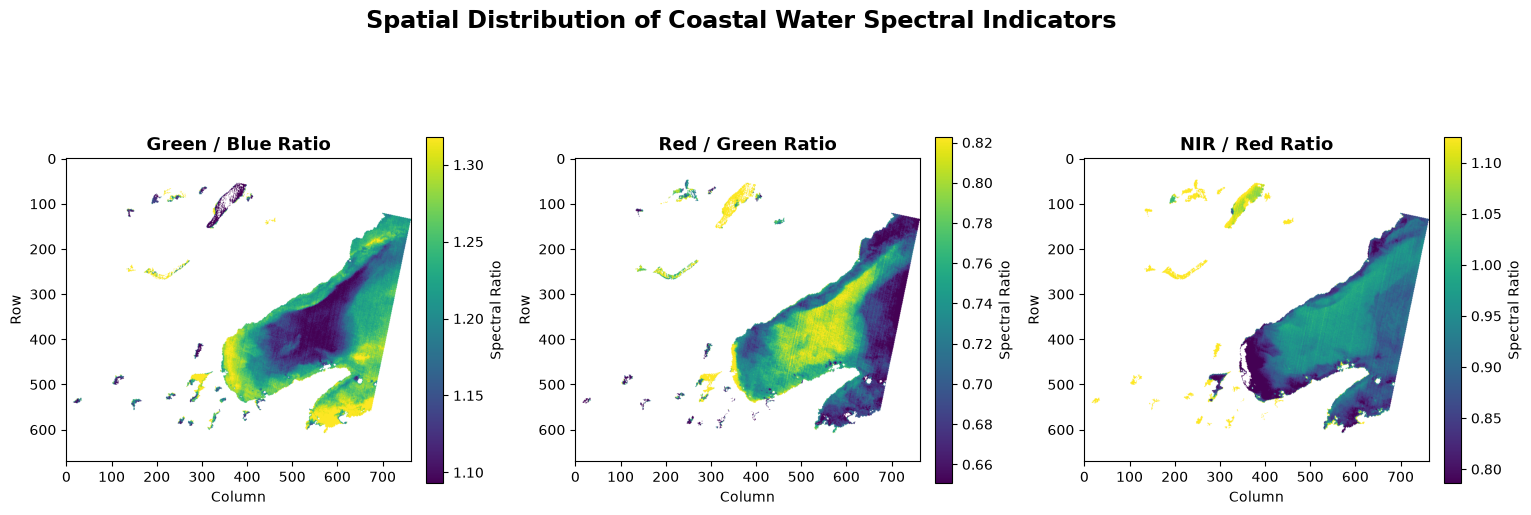

Figure exported:
C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_05\coastal_water_spectral_indicators.png


In [30]:
#29_Final spectral indicator maps

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

indicator_layers = [
    ("Green / Blue Ratio", green_blue_clean),
    ("Red / Green Ratio", red_green_clean),
    ("NIR / Red Ratio", nir_red_clean)
]

for ax, (name, layer) in zip(axes, indicator_layers):

    vmin = np.nanpercentile(layer, 5)
    vmax = np.nanpercentile(layer, 95)

    im = ax.imshow(
        layer,
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    ax.set_title(
        name,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label("Spectral Ratio")

fig.suptitle(
    "Spatial Distribution of Coastal Water Spectral Indicators",
    fontsize=17,
    fontweight="bold"
)

fig.subplots_adjust(
    top=0.85,
    wspace=0.35
)

final_map_path = OUTPUT_DIR / "coastal_water_spectral_indicators.png"

fig.savefig(
    final_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported:")
print(final_map_path)

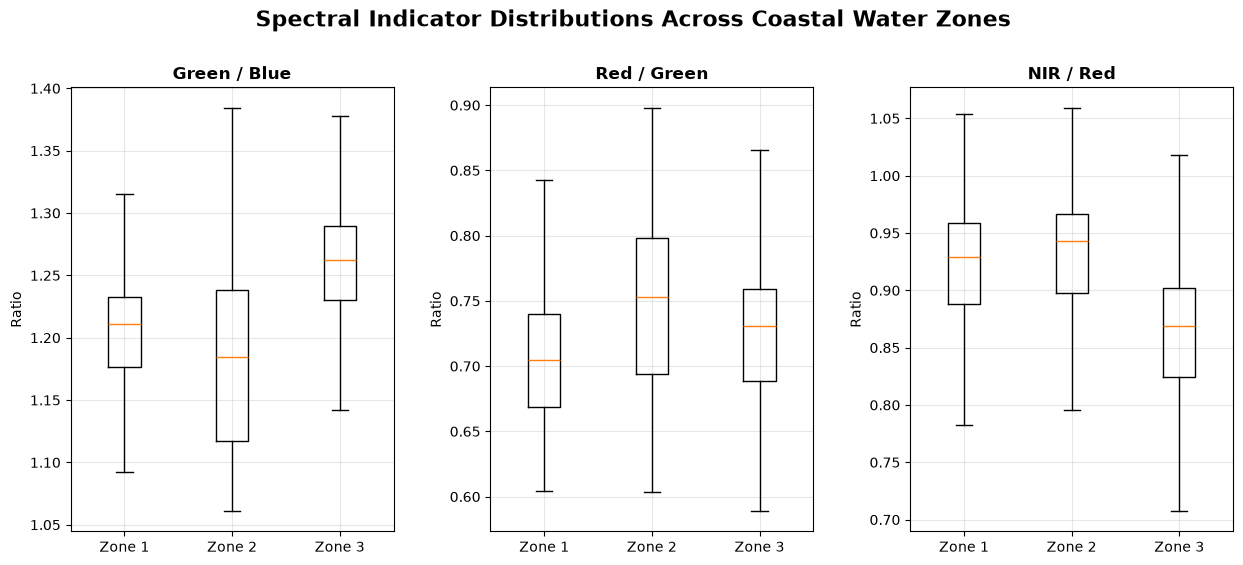

Figure exported:
C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_05\spectral_indicator_zone_comparison.png


In [31]:
#30_Final zone comparison figure

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 6)
)

indicator_names = [
    "Green / Blue",
    "Red / Green",
    "NIR / Red"
]

for ax, name in zip(axes, indicator_names):

    data = [
        zone_statistics[1][name],
        zone_statistics[2][name],
        zone_statistics[3][name]
    ]

    ax.boxplot(
        data,
        tick_labels=["Zone 1", "Zone 2", "Zone 3"],
        showfliers=False
    )

    ax.set_title(
        name,
        fontweight="bold"
    )

    ax.set_ylabel("Ratio")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Spectral Indicator Distributions Across Coastal Water Zones",
    fontsize=16,
    fontweight="bold"
)

fig.subplots_adjust(
    top=0.85,
    wspace=0.3
)

boxplot_path = OUTPUT_DIR / "spectral_indicator_zone_comparison.png"

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported:")
print(boxplot_path)

In [32]:
#31_Final interpretation

print("""
FINAL INTERPRETATION
============================================================

The analysis identified spatial variation in the optical properties
of coastal waters within the Planet Tanager scene over Corozal Bay,
Belize.

Three relative spectral indicators were investigated:

1. Green / Blue Ratio
2. Red / Green Ratio
3. NIR / Red Ratio

The three exploratory water zones showed different median spectral
responses.

Green / Blue:
Zone 1 = 1.2112
Zone 2 = 1.1846
Zone 3 = 1.2625

Red / Green:
Zone 1 = 0.7045
Zone 2 = 0.7533
Zone 3 = 0.7307

NIR / Red:
Zone 1 = 0.9289
Zone 2 = 0.9431
Zone 3 = 0.8687

The largest relative difference between zone medians was observed
for the NIR / Red indicator, followed by Red / Green and Green / Blue.

These results demonstrate spatially varying spectral characteristics
within the mapped coastal water body.

However, the indicators represent relative spectral patterns only.
They are not calibrated measurements of turbidity, chlorophyll-a,
suspended sediment concentration, or other water-quality parameters.

Independent field measurements and a validated retrieval model would
be required to convert these spectral indicators into quantitative
water-quality estimates.

Therefore, the results should be interpreted as exploratory
hyperspectral feature mapping rather than quantitative water-quality
retrieval.
""")


FINAL INTERPRETATION

The analysis identified spatial variation in the optical properties
of coastal waters within the Planet Tanager scene over Corozal Bay,
Belize.

Three relative spectral indicators were investigated:

1. Green / Blue Ratio
2. Red / Green Ratio
3. NIR / Red Ratio

The three exploratory water zones showed different median spectral
responses.

Green / Blue:
Zone 1 = 1.2112
Zone 2 = 1.1846
Zone 3 = 1.2625

Red / Green:
Zone 1 = 0.7045
Zone 2 = 0.7533
Zone 3 = 0.7307

NIR / Red:
Zone 1 = 0.9289
Zone 2 = 0.9431
Zone 3 = 0.8687

The largest relative difference between zone medians was observed
for the NIR / Red indicator, followed by Red / Green and Green / Blue.

These results demonstrate spatially varying spectral characteristics
within the mapped coastal water body.

However, the indicators represent relative spectral patterns only.
They are not calibrated measurements of turbidity, chlorophyll-a,
suspended sediment concentration, or other water-quality parameters.

I

In [33]:
#32_Analysis metadata

analysis_metadata = {
    "Study Area": "Corozal Bay, Belize",
    "Sensor": "Planet Tanager",
    "Data Product": "Surface Reflectance",
    "Spectral Range": "Approximately 376–2499 nm",
    "Number of Spectral Bands": len(wavelengths),
    "Water Mask Pixels": int(np.sum(water_mask)),
    "Main Water Body Pixels": 94550,
    "Spectral Indicators": "Green/Blue, Red/Green, NIR/Red",
    "Indicator Range Method": "5th–95th percentile for visualization",
    "Analysis Type": "Relative spectral feature analysis",
    "Calibration Data": "No coincident field measurements"
}

print("Analysis Metadata")
print("=" * 60)

for key, value in analysis_metadata.items():
    print(f"{key}: {value}")

Analysis Metadata
Study Area: Corozal Bay, Belize
Sensor: Planet Tanager
Data Product: Surface Reflectance
Spectral Range: Approximately 376–2499 nm
Number of Spectral Bands: 426
Water Mask Pixels: 103239
Main Water Body Pixels: 94550
Spectral Indicators: Green/Blue, Red/Green, NIR/Red
Indicator Range Method: 5th–95th percentile for visualization
Analysis Type: Relative spectral feature analysis
Calibration Data: No coincident field measurements
